## Import essential libraries

In [3]:
import os
from glob import glob
import matplotlib.pyplot as plt
import numpy as np
import PIL
import cv2
import shutil
import tensorflow as tf
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

In [2]:
sess = tf.compat.v1.Session(config=tf.compat.v1.ConfigProto(log_device_placement=True))

Device mapping:
/job:localhost/replica:0/task:0/device:GPU:0 -> device: 0, name: NVIDIA GeForce GTX 1050, pci bus id: 0000:01:00.0, compute capability: 6.1



In [3]:
gpu = tf.config.list_physical_devices('GPU')
gpu

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [4]:
if gpu:
    try:
        tf.config.set_visible_devices(gpu[0], 'GPU')
        logical_gpu = tf.config.list_logical_devices('GPU')
        print(len(gpu), len(logical_gpu))
    except Exception as e:
        print(str(e))

1 1


## data preprocessing and labeling

In [5]:
BASE_DIR = 'Malware_as_images/data_for_training/'
benign_class = os.path.join(BASE_DIR, 'benign')
malicious_class = os.path.join(BASE_DIR , 'malicious')

In [10]:
benign_images = glob(benign_class + '/*')
malicious_images = glob(malicious_class + '/*')

print(f'num of images in benign class : {len(benign_images)}')
print(f'num of images in malicious class : {len(malicious_images)}')

num of images in benign class : 468
num of images in malicious class : 574


In [6]:
train_dir = 'malimg_dataset9010/malimg_dataset/validation/'

In [6]:
# train_dir = 'Malware_as_images/data_for_training/'

In [7]:
# create dataloaders
img_height, img_width = 320, 320
batch_size = 16

# train dataloader
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  train_dir,
  validation_split = 0.2,
  subset = "training",
  seed = 123,
  image_size = (img_height, img_width),
  batch_size = batch_size)

# validation dataloader
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  train_dir,
  validation_split = 0.2,
  subset = "validation",
  seed = 123,
  image_size = (img_height, img_width),
  batch_size = batch_size)

Found 935 files belonging to 25 classes.
Using 748 files for training.
Found 935 files belonging to 25 classes.
Using 187 files for validation.


## Visualize data

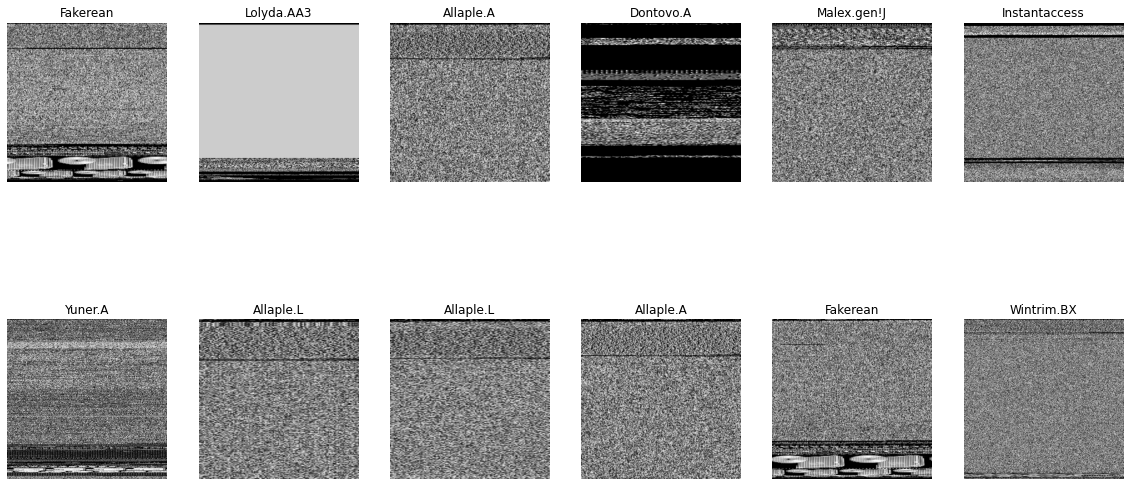

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize = (20, 10))
# classes = ['benign', 'malicious']
classes = os.listdir(train_dir)

for images, labels in train_ds.take(1):
    for i in range(12):
        ax = plt.subplot(2, 6, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(classes[labels[i]])
        plt.axis("off")

In [7]:
## Import pretrained model

In [8]:
resnet_model = Sequential()


# pretrained_model = tf.keras.applications.ResNet50(include_top = False,
#                    input_shape = (32, 32, 3),
#                    pooling = 'max',
#                    classes = 2,
#                    weights = 'imagenet')


# train on different parameters for resnet50v2 with different image shape
# pretrained_model = tf.keras.applications.ResNet50V2(include_top = False,
#                                                    input_shape = (32, 32, 3),
#                                                     pooling = "avg",
#                                                     classes = 2,
#                                                     weights = 'imagenet'
#                                                    ) 

pretrained_model = tf.keras.applications.ResNet101(include_top = False,
                                                   input_shape = (320, 320, 3),
                                                    pooling = "max",
                                                    classes = 2,
                                                    weights = 'imagenet'
                                                   )

for layer in pretrained_model.layers:
        layer.trainable = False

resnet_model.add(pretrained_model)

In [9]:
resnet_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
resnet101 (Functional)       (None, 2048)              42658176  
Total params: 42,658,176
Trainable params: 0
Non-trainable params: 42,658,176
_________________________________________________________________


In [10]:
resnet_model.add(Flatten())
resnet_model.add(Dense(256, activation = 'relu'))
resnet_model.add(Dense(2, activation = 'softmax'))

In [11]:
resnet_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
resnet101 (Functional)       (None, 2048)              42658176  
_________________________________________________________________
flatten (Flatten)            (None, 2048)              0         
_________________________________________________________________
dense (Dense)                (None, 256)               524544    
_________________________________________________________________
dense_1 (Dense)              (None, 2)                 514       
Total params: 43,183,234
Trainable params: 525,058
Non-trainable params: 42,658,176
_________________________________________________________________


In [12]:
checkpoint_filepath = 'weights/'

num_epochs = 50

resnet_model.compile(optimizer = Adam(lr = 0.001), 
                     loss = 'sparse_categorical_crossentropy', 
                     metrics = ['accuracy'])

model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath = checkpoint_filepath,
    save_weights_only = True,
    monitor = 'val_accuracy',
    mode = 'max',
    save_best_only = True)

history = resnet_model.fit(train_ds, validation_data = val_ds, epochs = num_epochs)

model.load_weights(checkpoint_filepath)


Epoch 1/50
53/53 [==============================] - 334s 5s/step - loss: 4.4161 - accuracy: 0.7145 - val_loss: 0.6659 - val_accuracy: 0.8606
Epoch 2/50
53/53 [==============================] - 321s 5s/step - loss: 0.3437 - accuracy: 0.8859 - val_loss: 0.4231 - val_accuracy: 0.9135
Epoch 3/50
53/53 [==============================] - 328s 6s/step - loss: 0.2448 - accuracy: 0.9350 - val_loss: 0.1327 - val_accuracy: 0.9375
Epoch 4/50
53/53 [==============================] - 327s 6s/step - loss: 0.0797 - accuracy: 0.9713 - val_loss: 0.1324 - val_accuracy: 0.9423
Epoch 5/50
53/53 [==============================] - 331s 6s/step - loss: 0.1021 - accuracy: 0.9561 - val_loss: 0.0972 - val_accuracy: 0.9519
Epoch 6/50
53/53 [==============================] - 335s 6s/step - loss: 0.0617 - accuracy: 0.9790 - val_loss: 0.0951 - val_accuracy: 0.9615
Epoch 7/50
53/53 [==============================] - 333s 6s/step - loss: 0.0441 - accuracy: 0.9807 - val_loss: 0.0765 - val_accuracy: 0.9760
Epoch 8/50
53

NameError: name 'model' is not defined

In [13]:
resnet_model.save("weights/resnet_101_320x320.h5")

## Evaluate

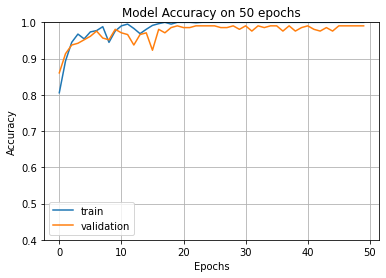

<Figure size 720x720 with 0 Axes>

In [14]:
fig1 = plt.gcf()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.axis(ymin = 0.4, ymax = 1)
plt.grid()
plt.title(f'Model Accuracy on {num_epochs} epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.figure(figsize = (10, 10))
plt.show()

## Model Inference

In [23]:
class_names = ['benign', 'malicious']

In [15]:
some_other_sources_data = glob('malimg_dataset9010/validation/**/*.png')
test_data = glob('Malware_as_images/test_data/**/*')

In [30]:
n = np.random.randint(0, len(test_data))
# img_path = benign_images[n]
# img_path = malicious_images[n]
# img_path = some_other_sources_data[n]
img_path = test_data[n]
print(img_path)

Malware_as_images/test_data/malicious/malicious_1086.png


In [31]:
image = cv2.imread(img_path)
image_resized = cv2.resize(image, (320, 320))
image = np.expand_dims(image_resized, axis = 0)

In [32]:
pred = resnet_model.predict(image)

In [33]:
output_class = class_names[np.argmax(pred)]
print("The predicted class is", output_class)

The predicted class is malicious


In [17]:
import random
from tqdm import tqdm

for img in tqdm(random.sample(malicious_images, 10000)):
    file_name = img.split('/')[-1]
    shutil.copyfile(img, f'converted_images/malicious_less_data/{file_name}')

100%|██████████| 10000/10000 [05:17<00:00, 31.47it/s]
